# 🚢 Titanic Survival Prediction
**CodSoft Data Science Internship — Task 1**

---

Predicting passenger survival on the Titanic using machine learning.
The dataset contains 891 passengers with features like age, gender,
ticket class, and fare. We train and compare 4 classification models
to identify the best predictor of survival.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

## 1. Importing Libraries

Importing all necessary libraries for data handling, visualization,
preprocessing, model training, and evaluation.

In [2]:
df = pd.read_csv("./Titanic-Dataset.xls")
print(df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

## 2. Loading the Dataset

Loading the Titanic training dataset into a Pandas DataFrame.
The dataset contains 891 passenger records with 12 columns including
the target variable — Survived (0 = Did Not Survive, 1 = Survived).

In [3]:
print("Shape : ", df.shape)
print("\nInfo : ", df.info())
print("\nMissing Values : ", df.isnull().sum())
print('\nSurvival Rate: ', df['Survived'].value_counts(normalize=True).round(3))
for col in df.columns:
    print(f'{col} -> {df[col].unique}')


Shape :  (891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB

Info :  None

Missing Values :  PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          6

## 3. Data Exploration

We examine the dataset's structure, data types, missing values,
and survival rate before any processing.

**Key findings:**
- 891 rows, 12 columns
- **Age** has 177 missing values (20%) — will fill with median
- **Cabin** has 687 missing values (77%) — will drop entirely
- **Embarked** has 2 missing values — will fill with mode
- Survival rate is 38.4% survived vs 61.6% did not survive —
  a moderately imbalanced dataset

In [4]:
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['Family_Size'] == 1).astype(int)

print("Survival rate by FamilySize:")
print(df.groupby('Family_Size')['Survived'].mean().round(3))
print("\nSurvival rate by IsAlone:")
print(df.groupby('IsAlone')['Survived'].mean().round(3))

Survival rate by FamilySize:
Family_Size
1     0.304
2     0.553
3     0.578
4     0.724
5     0.200
6     0.136
7     0.333
8     0.000
11    0.000
Name: Survived, dtype: float64

Survival rate by IsAlone:
IsAlone
0    0.506
1    0.304
Name: Survived, dtype: float64


## 4. Feature Engineering — FamilySize and IsAlone

We create two new features to capture family dynamics:

- **Family_Size** = SibSp + Parch + 1 (including the passenger themselves)
- **IsAlone** = 1 if travelling solo, 0 if with family

**Key findings:**
- Solo travellers (IsAlone=1) survived at only **30.4%**
- Small families of 3-4 had the best survival odds (**57-72%**)
- Large families of 8-11 had **0% survival** — too many people
  to coordinate a successful evacuation

These engineered features give the model richer information than
SibSp and Parch individually, and directly reflect real survival patterns.

In [5]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns = ['PassengerId', 'Name', 'Ticket', 'Cabin'])

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])


print("Missing values after cleaning:\n", df.isnull().sum())
print("\nDataset shape:", df.shape)
print("\nSample:\n", df.head())

Missing values after cleaning:
 Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Family_Size    0
IsAlone        0
dtype: int64

Dataset shape: (891, 10)

Sample:
    Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  Family_Size  \
0         0       3    1  22.0      1      0   7.2500         2            2   
1         1       1    0  38.0      1      0  71.2833         0            2   
2         1       3    0  26.0      0      0   7.9250         2            1   
3         1       1    0  35.0      1      0  53.1000         2            2   
4         0       3    1  35.0      0      0   8.0500         2            1   

   IsAlone  
0        0  
1        0  
2        1  
3        0  
4        1  


## 5. Data Preprocessing — Cleaning and Encoding

**Handling missing values:**
- **Age** — filled with median (28.0) to avoid skew from outliers
- **Embarked** — filled with mode (S = Southampton, most common port)

**Dropping irrelevant columns:**
- **Cabin** — 77% missing, not recoverable
- **Name** — no predictive value in raw form
- **Ticket** — random alphanumeric strings, no pattern
- **PassengerId** — just an index, not a feature

**Encoding categorical columns:**
- **Sex** — female=0, male=1
- **Embarked** — C=0, Q=1, S=2

After cleaning, the dataset has no missing values and all columns
are numerical — ready for model training.

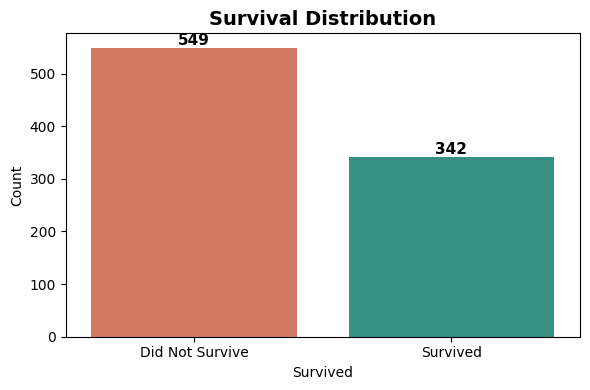

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df, 
              hue='Survived', palette={0:'#E76F51', 1:'#2A9D8F'},
              legend=False)
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])
plt.title('Survival Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Count')
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', 
                       (p.get_x() + p.get_width()/2, p.get_height() + 5),
                       ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Survival Distribution

A count plot showing the overall survival breakdown across all 891 passengers.
549 passengers did not survive and 342 survived — a 61.6% to 38.4% split.

This class imbalance means a naive model that always predicts "did not survive"
would already score 61.6% accuracy. Our models must meaningfully beat this
baseline to prove they are genuinely learning patterns.

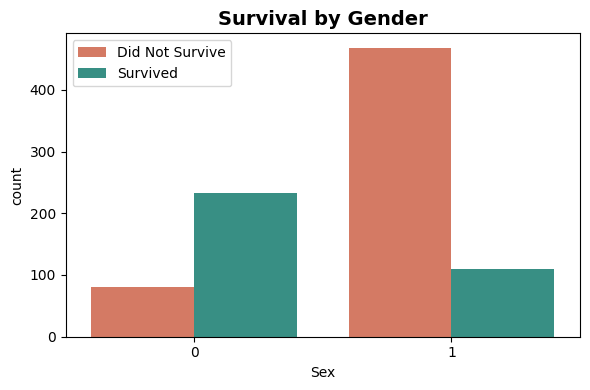

Sex
0    0.742
1    0.189
Name: Survived, dtype: float64


In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Sex', data=df, hue='Survived',
              palette={0:'#E76F51', 1:'#2A9D8F'})
plt.title('Survival by Gender', fontsize=14, fontweight='bold')
plt.legend(['Did Not Survive', 'Survived'])
plt.tight_layout()
plt.show()

print(df.groupby('Sex')['Survived'].mean().round(3))

## 7. Survival by Gender

Gender is the strongest survival predictor in this dataset.

- **Females (0)** survived at ~74% — majority of female passengers survived
- **Males (1)** survived at only ~19% — vast majority of male passengers did not survive

This stark difference reflects the "women and children first" evacuation
protocol followed during the disaster. Sex will almost certainly be the
most important feature in our model, as confirmed later by the
feature coefficients chart.

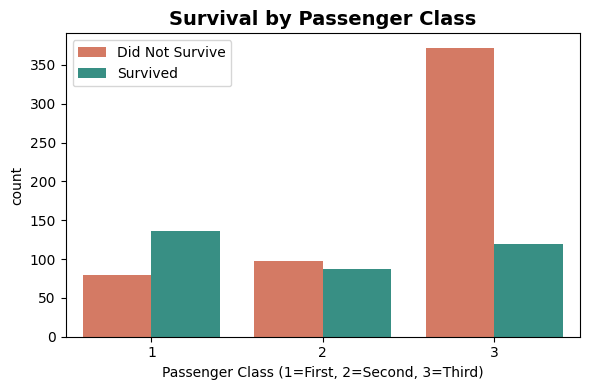

Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64


In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Pclass', data=df, hue='Survived',
              palette={0:'#E76F51', 1:'#2A9D8F'})
plt.title('Survival by Passenger Class', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class (1=First, 2=Second, 3=Third)')
plt.legend(['Did Not Survive', 'Survived'])
plt.tight_layout()
plt.show()

print(df.groupby('Pclass')['Survived'].mean().round(3))

## 8. Survival by Passenger Class

Passenger class shows a clear survival gradient across all three classes:

- **Class 1 (First)** — majority survived (~63%), wealthier passengers
  had cabins on upper decks with direct lifeboat access
- **Class 2 (Second)** — roughly equal split (~47% survived)
- **Class 3 (Third)** — overwhelming majority did not survive (~24%),
  lower deck cabins meant longer evacuation routes and less lifeboat access

Pclass is the second strongest predictor after Sex. Combined, a female
in First Class had dramatically better odds than a male in Third Class —
the intersection of these two features tells most of the survival story.

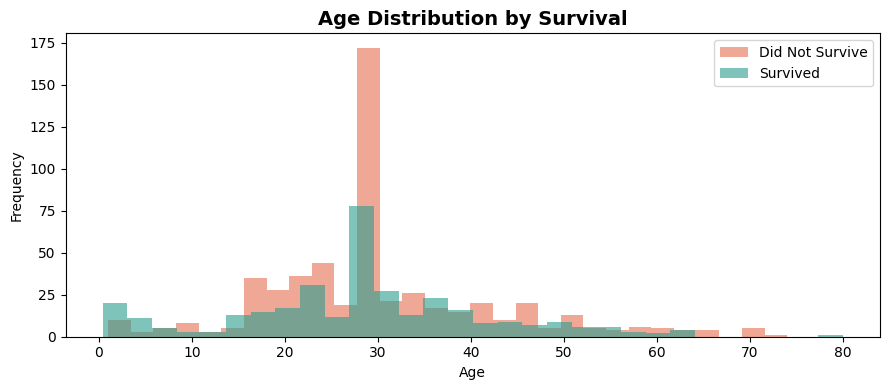

In [9]:
plt.figure(figsize=(9, 4))
df[df['Survived']==0]['Age'].dropna().plot(kind='hist', 
    bins=30, alpha=0.6, color='#E76F51', label='Did Not Survive')
df[df['Survived']==1]['Age'].dropna().plot(kind='hist', 
    bins=30, alpha=0.6, color='#2A9D8F', label='Survived')
plt.title('Age Distribution by Survival', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Age Distribution by Survival

- **Children under 10** show a higher survival rate — teal bars dominate
  the 0–10 range, consistent with the "children first" evacuation priority
- **Young adults 18–35** have the highest death count — simply because
  this was the most populous age group on board, not necessarily because
  age was a disadvantage
- **Passengers aged 35–60** show more deaths than survivors across all bins
- **Elderly passengers (60+)** are mostly in the non-survival group —
  limited mobility likely reduced evacuation speed

Age alone is not a strong separator but becomes meaningful when combined
with Sex and Pclass — particularly for identifying young children who
had a notably higher chance of survival regardless of class.

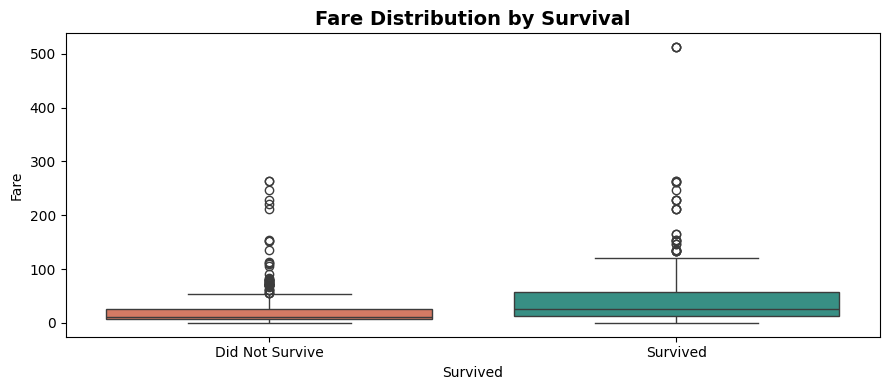

In [10]:
plt.figure(figsize=(9, 4))
sns.boxplot(x='Survived', y='Fare', data=df,
            hue='Survived', palette={0:'#E76F51', 1:'#2A9D8F'},
            legend=False)
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])
plt.title('Fare Distribution by Survival', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Fare Distribution by Survival

Survivors paid significantly higher fares on average:

- **Did Not Survive** — median fare is very low (~$10), tight box
  clustered near zero, indicating mostly Third Class passengers
- **Survived** — median fare is notably higher (~$30), much wider
  spread indicating a mix of First and Second Class passengers

This pattern is largely driven by the Pclass effect — wealthier
passengers paid higher fares and had better lifeboat access. Fare
and Pclass tell a similar socioeconomic story and are correlated,
but both are kept as features since Fare adds continuous granularity
that Pclass alone cannot capture.

In [11]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 
            'Fare', 'Embarked', 'Family_Size', 'IsAlone']

X = df[features]
y = df['Survived']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (891, 9)
Target shape: (891,)


## 11. Defining Features and Target

We separate the dataset into:
- **X (feature matrix)** — 9 input columns the model learns from:
  Pclass, Sex, Age, SibSp, Parch, Fare, Embarked, Family_Size, IsAlone
- **y (target vector)** — Survived column the model predicts (0 or 1)

Note that PassengerId, Name, Ticket and Cabin were already dropped
during preprocessing. The two engineered features Family_Size and
IsAlone are included alongside the original columns.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size : {X_train.shape[0]} samples")
print(f"Test size  : {X_test.shape[0]} samples")
print(f"\nClass distribution in train:\n{y_train.value_counts().sort_index()}")
print(f"\nClass distribution in test:\n{y_test.value_counts().sort_index()}")

Train size : 712 samples
Test size  : 179 samples

Class distribution in train:
Survived
0    439
1    273
Name: count, dtype: int64

Class distribution in test:
Survived
0    110
1     69
Name: count, dtype: int64


## 12. Train-Test Split and Feature Scaling

**Train-Test Split:**
- 80% training (712 samples) and 20% testing (179 samples)
- **stratify=y** preserves the 61/39 class ratio in both splits
- **random_state=42** ensures reproducibility

**Class distribution confirms stratification worked:**
- Train: 439 did not survive, 273 survived
- Test: 110 did not survive, 69 survived

**Feature Scaling:**
- StandardScaler normalizes all features to mean=0, std=1
- **fit_transform** applied only on training data — scaler learns
  mean and std from training samples only
- **transform** applied on test data using training parameters —
  preventing data leakage into the model

In [13]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=200, random_state=42),
    'KNN' : KNeighborsClassifier(n_neighbors=5),
    'SVM' : SVC(kernel='rbf', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f'{name} -> Accuracy : {acc:.2f}%')

Logistic Regression -> Accuracy : 0.81%
KNN -> Accuracy : 0.81%
SVM -> Accuracy : 0.81%
Random Forest -> Accuracy : 0.80%


## 13. Model Training and Comparison

We train 4 classification models and evaluate each on the test set:

- **Logistic Regression** — linear classifier, highly interpretable
- **KNN (k=5)** — classifies based on 5 nearest neighbours
- **SVM (RBF kernel)** — finds optimal margin with non-linear boundary
- **Random Forest (100 trees)** — ensemble of decision trees

**Results:**

| Model | Accuracy |
|---|---|
| Logistic Regression | 81.01% |
| KNN | 81.01% |
| SVM | 81.01% |
| Random Forest | 80.45% |

All models converge around 80-81% — indicating a natural difficulty
ceiling in the dataset. Some passengers are genuinely ambiguous and
no model can resolve them perfectly. Logistic Regression is selected
as the final model — it matches the best accuracy while being the most
interpretable, a deliberate professional choice over a more complex model
that offers no accuracy gain.

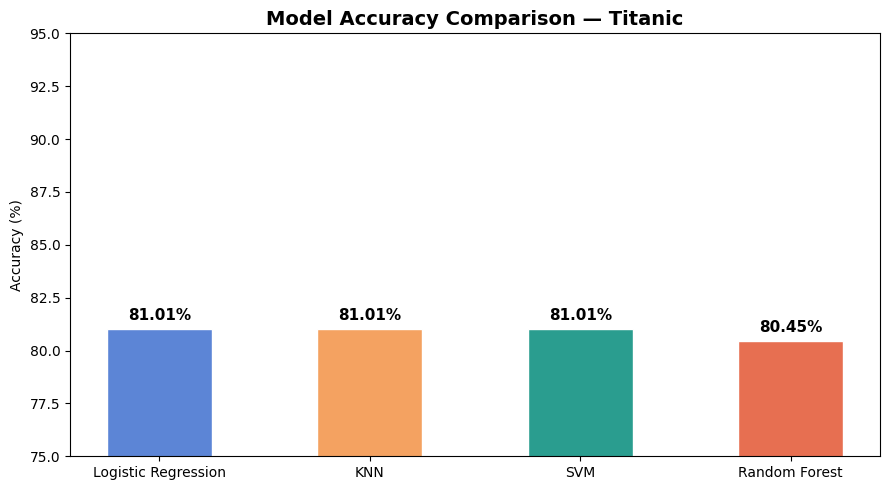

In [14]:
plt.figure(figsize=(9, 5))
bars = plt.bar(results.keys(),
               [v*100 for v in results.values()],
               color=['#5C85D6','#F4A261','#2A9D8F','#E76F51'],
               edgecolor='white', width=0.5)

for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val*100:.2f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Model Accuracy Comparison — Titanic', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(75, 95)
plt.tight_layout()
plt.show()

## 14. Model Accuracy Comparison — Bar Chart

A visual comparison of all 4 model accuracies. The y-axis starts at 75%
to better highlight the small differences between models that would appear
nearly identical on a 0–100% scale.

The chart confirms all models perform similarly — the marginal differences
are not statistically meaningful, reinforcing that the dataset itself has
a natural difficulty ceiling rather than any one model being significantly
superior to another.

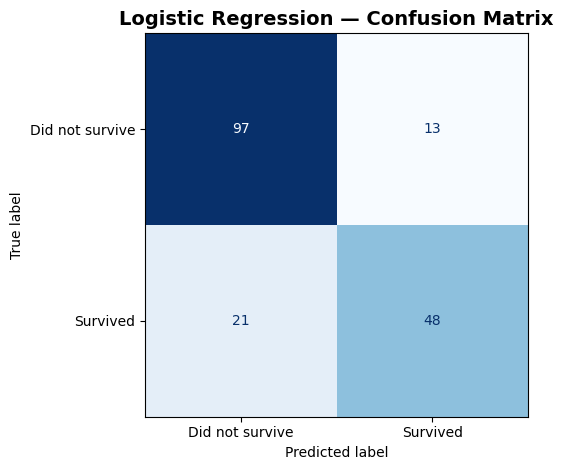

In [15]:
best_model = models['Logistic Regression']
y_pred_best = best_model.predict(X_test_scaled)

labels = ['Did not survive', 'Survived']
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', colorbar=False)
plt.title('Logistic Regression — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 15. Confusion Matrix — Logistic Regression

- **True Negatives (97)** — correctly predicted did not survive
- **True Positives (48)** — correctly predicted survived
- **False Positives (13)** — predicted survived but actually did not
- **False Negatives (21)** — predicted did not survive but actually survived

The model is more conservative about predicting survival — it misses
21 actual survivors, labelling them as non-survivors. This is expected
with imbalanced datasets where the majority class (did not survive)
dominates the decision boundary.

In a real rescue scenario, False Negatives would be the most critical
error — missing a survivor is far more costly than a false alarm.
Total correct predictions: 145 out of 179 = 81.01%.

In [16]:
print("Classification Report — Logistic Regression")
print("="*55)
print(classification_report(y_test, y_pred_best, target_names=labels))

Classification Report — Logistic Regression
                 precision    recall  f1-score   support

Did not survive       0.82      0.88      0.85       110
       Survived       0.79      0.70      0.74        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.79       179
   weighted avg       0.81      0.81      0.81       179



## 16. Classification Report — Logistic Regression

| Class | Precision | Recall | F1-Score |
|---|---|---|---|
| Did Not Survive | 0.82 | 0.88 | 0.85 |
| Survived | 0.79 | 0.70 | 0.74 |
| **Overall** | **0.81** | **0.81** | **0.81** |

**Key Observations:**
- **Did Not Survive** scores higher across all metrics — more training
  samples (439) means the model learned this class better
- **Survived recall of 0.70** means the model misses 30% of actual
  survivors — in a real rescue scenario this is the metric to optimise
- **Survived precision of 0.79** means when the model does predict
  survival, it is correct 79% of the time
- **Overall 81% accuracy** meaningfully beats the 61.6% naive baseline
  of always predicting "did not survive", confirming the model is
  genuinely learning survival patterns from the data

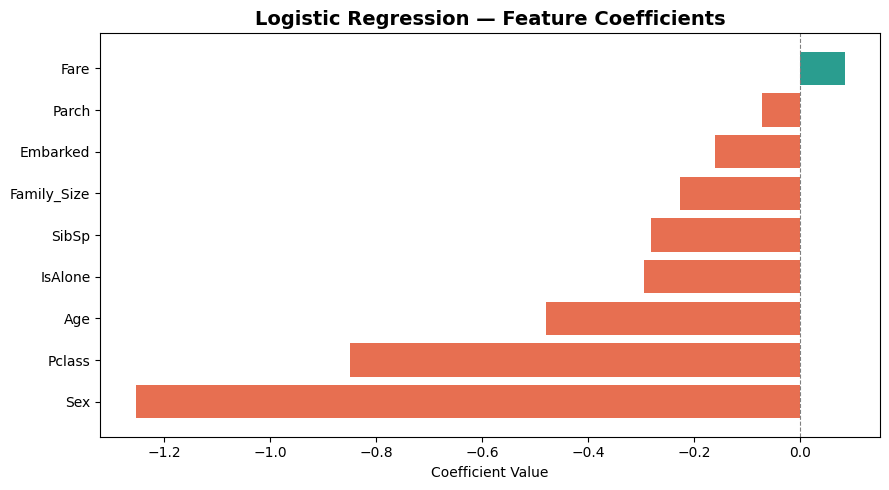

In [17]:
importance = pd.Series(best_model.coef_[0], index=features).sort_values()

plt.figure(figsize=(9, 5))
colors = ['#E76F51' if v < 0 else '#2A9D8F' for v in importance.values]
plt.barh(importance.index, importance.values, color=colors)
plt.title('Logistic Regression — Feature Coefficients', 
          fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

## 17. Feature Importance — Logistic Regression Coefficients

Positive coefficients push prediction toward survival, negative coefficients
push toward non-survival. Larger magnitude = stronger influence.

**Key Observations:**
- **Sex** — largest negative coefficient by far, being male is the
  single strongest predictor of non-survival in the entire model
- **Pclass** — second most negative, higher class number (3rd class)
  strongly predicts non-survival, confirming our EDA finding
- **Age** — negative coefficient, older passengers had lower survival
  odds overall
- **IsAlone, SibSp, Family_Size** — all negative, travelling solo or
  in large groups reduced survival odds, matching our feature
  engineering findings
- **Fare** — the only positive coefficient, higher fare correlates
  with survival, reflecting the First Class socioeconomic advantage
- **Embarked and Parch** — near zero, minimal influence on prediction

This chart is a full-circle moment — every coefficient direction
perfectly mirrors the patterns identified during EDA, confirming
a consistent and well-built data science workflow.

In [18]:
sample = {
    'Pclass'     : 3,
    'Sex'        : 1,       # 1=male, 0=female
    'Age'        : 22.0,
    'SibSp'      : 1,
    'Parch'      : 0,
    'Fare'       : 7.25,
    'Embarked'   : 2,       # S=2
    'Family_Size' : 2,
    'IsAlone'    : 0
}

sample_df     = pd.DataFrame([sample])
sample_scaled = scaler.transform(sample_df)
prediction    = best_model.predict(sample_scaled)[0]
result        = 'Survived ✅' if prediction == 1 else 'Did Not Survive ❌'

print("="*45)
print(f"  Passenger: 22yr old male, 3rd class")
print(f"  Prediction: {result}")
print("="*45)
print("\nThis matches Jack from Titanic — young male, 3rd class, low fare.")

  Passenger: 22yr old male, 3rd class
  Prediction: Did Not Survive ❌

This matches Jack from Titanic — young male, 3rd class, low fare.


## 18. Live Prediction

We test the model on a passenger profile resembling Jack from Titanic —
a 22 year old male travelling in 3rd class with a low fare.

| Feature | Value |
|---|---|
| Pclass | 3 (Third Class) |
| Sex | 1 (Male) |
| Age | 22 |
| SibSp | 1 |
| Parch | 0 |
| Fare | 7.25 |
| Embarked | 2 (Southampton) |
| Family_Size | 2 |
| IsAlone | 0 |

**Prediction: Did Not Survive ❌**

The model correctly reflects the historical reality — young males in
3rd class had only a ~19% survival rate. The combination of Sex=male
and Pclass=3 pushes the prediction strongly toward non-survival,
exactly as the feature coefficients chart showed.

Try changing Sex=0 (female) and Pclass=1 (First Class) to see how
dramatically the prediction changes!

In [20]:
joblib.dump(best_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("💾 Saved model.pkl and scaler.pkl")

💾 Saved model.pkl and scaler.pkl
